In [1]:
import torch
from model import GPT, GPTConfig

config = GPTConfig(n_layers=2, d_model=64, n_heads=4)
model = GPT(config)

# dummy input — batch of 2 sequences, 16 tokens each
idx = torch.randint(0, config.vocab_size, (2, 16))
print(f"Input shape: {idx.shape}")
print(f"Model params: {model.count_params():,}")

Input shape: torch.Size([2, 16])
Model params: 1,139,328


## Embeddings

We have two separate embeddings — one for **token identity** (what the token is) and one for **position** (where it appears in the sequence). Transformers have no built-in sense of order, so position must be explicitly injected.

We **add** them instead of concatenating to maintain the `d_model` dimension. Concatenating would double the vector size to 128 with no proven benefit.
```python
x = tok_emb + pos_emb  # both (2, 16, 64) → result (2, 16, 64)
```

The resulting shape `(2, 16, 64)` means:
- `2` — batch size (2 sequences processed in parallel)
- `16` — sequence length (16 tokens)
- `64` — `d_model`, the size of the vector representing each token

In [2]:
# token embedding: maps each token id to a vector
tok_emb = model.tok_emb(idx)
print(f"Token embeddings shape: {tok_emb.shape}")  # (2, 16, 64)

# positional embedding: maps each position 0..15 to a vector
positions = torch.arange(16)
pos_emb = model.pos_emb(positions)
print(f"Positional embeddings shape: {pos_emb.shape}")  # (16, 64)

# add them together — this is x, the input to the first block
x = tok_emb + pos_emb
print(f"x shape after embeddings: {x.shape}")  # (2, 16, 64)

Token embeddings shape: torch.Size([2, 16, 64])
Positional embeddings shape: torch.Size([16, 64])
x shape after embeddings: torch.Size([2, 16, 64])


## Self-Attention

The input `x` is first normalized with LayerNorm, then projected into **Query, Key, and Value** matrices via a single linear layer of size `d_model → 3 * d_model`.
```python
qkv = block.attn.qkv(x_norm)  # (2, 16, 192) — 192 = 64 * 3
Q, K, V = qkv.split(C, dim=2)  # each (2, 16, 64)
```

Then each is reshaped into **multiple heads**. Instead of one big attention operation, we split into 4 smaller independent ones — each head learns to attend to different aspects of the sequence (syntax, semantics, position).
```python
Q = Q.view(B, T, n_heads, d_head).transpose(1, 2)  # (2, 4, 16, 16)
# batch, n_heads, seq_len, d_head
```

- `2` — batch size
- `4` — number of heads
- `16` — sequence length
- `16` — d_head (64 / 4)

In [4]:
# manually extract Q, K, V from the first block's attention layer
block = model.blocks[0]
x_norm = block.ln1(x)  # layernorm first

B, T, C = x_norm.shape
qkv = block.attn.qkv(x_norm)
Q, K, V = qkv.split(C, dim=2)

print(f"QKV shape before split: {qkv.shape}")
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")

# reshape for multi-head
Q = Q.view(B, T, block.attn.n_heads, block.attn.d_head).transpose(1, 2)
print(f"Q shape after reshape: {Q.shape}")  # (batch, n_heads, seq_len, d_head)

QKV shape before split: torch.Size([2, 16, 192])
Q shape: torch.Size([2, 16, 64])
K shape: torch.Size([2, 16, 64])
V shape: torch.Size([2, 16, 64])
Q shape after reshape: torch.Size([2, 4, 16, 16])


## Attention Weights Visualization

The causal mask (`is_causal=True`) enforces the lower triangular pattern — position `i` can only attend to positions `0..i`, never the future. The upper triangle is masked to `-inf` before softmax, resulting in zero attention there.

As we go lower (higher query positions), attention spreads across more key positions — position 0 can only attend to itself, position 15 can attend to all 16 positions. This is why the colors fade toward the bottom right.

This is an untrained model so the pattern is noisy — after training, heads develop structured patterns like attending to recent tokens or specific syntactic relationships.

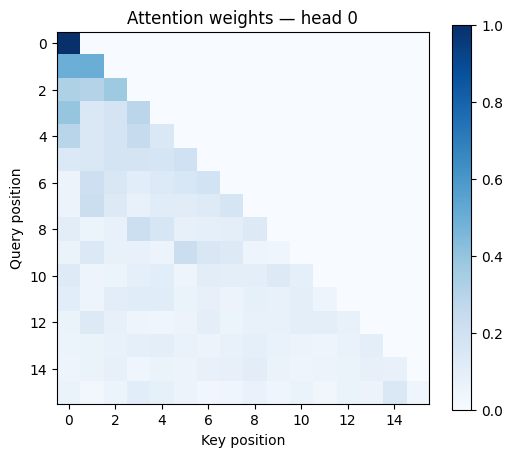

In [5]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# compute attention scores for head 0
K = K.view(B, T, block.attn.n_heads, block.attn.d_head).transpose(1, 2)
scores = Q @ K.transpose(-2, -1) / (block.attn.d_head ** 0.5)  # (2, 4, 16, 16)

# apply causal mask
mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
scores = scores.masked_fill(mask, float('-inf'))
attn_weights = F.softmax(scores, dim=-1)

# plot head 0, sequence 0
plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0, 0].detach().numpy(), cmap='Blues')
plt.title("Attention weights — head 0")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.colorbar()
plt.show()

## Full Forward Pass

The input ids pass through every component of the model. Notice that the shape stays `(1, 16, 64)` throughout all blocks — every block takes `(B, T, d_model)` and outputs `(B, T, d_model)`. This is what makes transformers stackable — you can add as many layers as you want and the interface stays identical.

The only shape change happens at the very end:
```python
logits = model.lm_head(x)  # (1, 16, 64) → (1, 16, 16000)
```

The `lm_head` projects each position's `d_model` vector into a distribution over all 16000 tokens — giving us 16 predictions in one forward pass.

In [6]:
# full forward pass, printing shapes at each stage
idx_sample = idx[0].unsqueeze(0)  # single sequence (1, 16)
print(f"Input ids: {idx_sample.shape}")

tok = model.tok_emb(idx_sample)
pos = model.pos_emb(torch.arange(16))
x = tok + pos
print(f"After embeddings: {x.shape}")

for i, block in enumerate(model.blocks):
    x = block(x)
    print(f"After block {i}: {x.shape}")

x = model.ln_f(x)
print(f"After final LayerNorm: {x.shape}")

logits = model.lm_head(x)
print(f"Logits: {logits.shape}")  # (1, 16, vocab_size)

Input ids: torch.Size([1, 16])
After embeddings: torch.Size([1, 16, 64])
After block 0: torch.Size([1, 16, 64])
After block 1: torch.Size([1, 16, 64])
After final LayerNorm: torch.Size([1, 16, 64])
Logits: torch.Size([1, 16, 16000])


## Loss Computation

Cross entropy loss measures how wrong the model's predictions are. It looks at the probability assigned to the correct next token — if that probability is low, loss is high.

For a perfectly random model with uniform logits, the expected loss is:
```python
loss_random = log(vocab_size) = log(16000) ≈ 9.68
```

Our untrained model gives `42.9` — much higher. This is because random weight initialization produces large logit values. Softmax then becomes overconfident, assigning near-zero probability to most tokens including the correct one. `-log(~0)` = very large loss.

This is why **weight initialization** matters — scaling weights small enough that initial logits are near zero gives roughly uniform output and a loss close to the theoretical random baseline.

Loss drops quickly in the first training steps as the model learns the basic token distribution.

In [7]:
import torch.nn.functional as F

# targets are the next tokens
x_input = idx_sample[:, :-1]   # (1, 15) — input tokens
y_target = idx_sample[:, 1:]   # (1, 15) — target tokens

logits = model(x_input)  # (1, 15, 16000)
print(f"Logits shape: {logits.shape}")

# flatten for cross entropy
loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y_target.view(-1))
print(f"Loss: {loss.item():.4f}")

# what does random loss look like?
import math
print(f"Expected random loss: {math.log(16000):.4f}")

Logits shape: torch.Size([1, 15, 16000])
Loss: 42.9093
Expected random loss: 9.6803
